<a href="https://colab.research.google.com/github/DanyRE4020/Concentracion_IA_avanzada/blob/main/Notebook4_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor


# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Create models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} - Mean Squared Error: {mse}")



Linear Regression - Mean Squared Error: 2900.193628493482
Ridge - Mean Squared Error: 3077.41593882723
Random Forest - Mean Squared Error: 2937.7295696629217


Linear Regression - MAE = 52.26
Ridge - MAE = 55.96
Lasso - MAE = 54.28


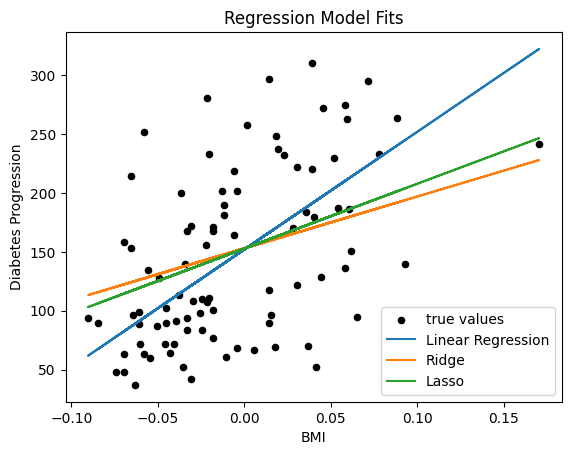

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

X = diabetes.data[:,np.newaxis,2]
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

plt.scatter(X_test, y_test, color='black', s=20, marker='o', label='true values')
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    plt.plot(X_test, predictions, label=name)
    mae = mean_absolute_error(y_test, predictions)
    print(f"{name} - MAE = {mae:.2f}")

plt.xlabel('BMI')
plt.ylabel('Diabetes Progression')
plt.title('Regression Model Fits')
plt.legend()
plt.show()

Linear Regression RMSE: 62.33
Decision Tree RMSE: 68.98
Random Forest RMSE: 66.05


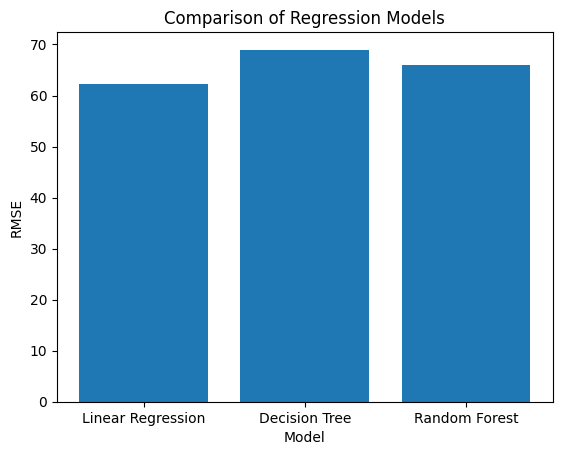

In [5]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

rmse_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmse_scores.append((name, rmse))
    print(f"{name} RMSE: {rmse:.2f}")

names, scores = zip(*rmse_scores)

plt.bar(names, scores)
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Model RMSE Score Comparisons')
plt.show()

Linear Regression R^2 Score: 0.28
Decision Tree R^2 Score: 0.12
Random Forest R^2 Score: 0.19


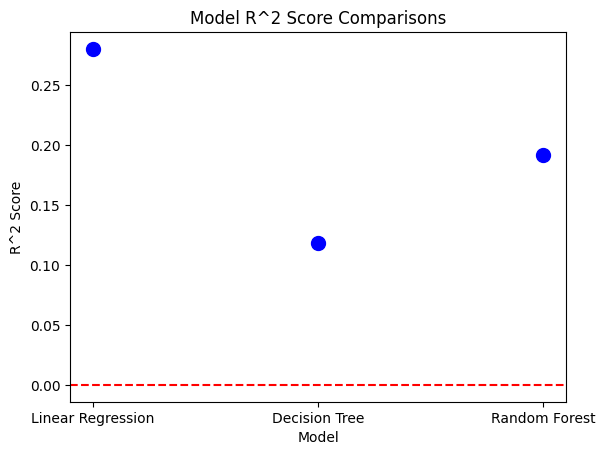

In [12]:
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

r2_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    r2_scores.append((name, r2))
    print(f"{name} R^2 Score: {r2:.2f}")

names, scores = zip(*r2_scores)
plt.scatter(names, scores, color='blue', s=100)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Model')
plt.ylabel('R^2 Score')
plt.title('Model R^2 Score Comparisons')
plt.show()

Linear Regression MAPE: 37.50%
Ridge MAPE: 42.57%
Lasso MAPE: 47.11%
Decision Tree MAPE: 45.44%
Random Forest MAPE: 40.01%
SVR MAPE: 49.03%


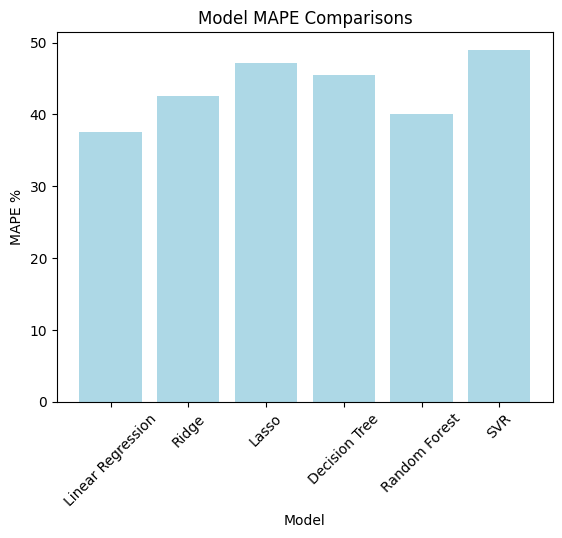

In [32]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())
]

mape_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, predictions)
    mape_scores.append((name, mape))
    print(f"{name} MAPE: {mape:.2f}%")

names, scores = zip(*mape_scores)
plt.bar(names, scores, color='lightblue')
plt.xlabel('Model')
plt.ylabel('MAPE %')
plt.title('Model MAPE Comparisons')
plt.xticks(rotation=45)
plt.show()
# Girar los labels

Linear Regression RMSE: 0.42
Ridge RMSE: 0.43
Lasso RMSE: 0.46
Decision Tree RMSE: 0.56
Random Forest RMSE: 0.42
SVR RMSE: 0.48


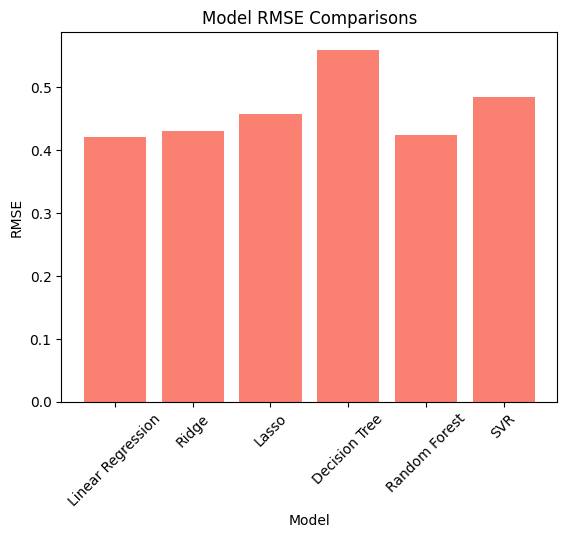

In [25]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error

import numpy as np
import matplotlib.pyplot as plt
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def root_mean_squared_error(y_true, y_pred):
    y_pred =np.clip(y_pred, 1e-10, np.inf)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())
]

rmse_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, predictions)
    rmse_scores.append((name, rmse))
    print(f"{name} RMSE: {rmse:.2f}")

names, scores = zip(*rmse_scores)
plt.bar(names, scores, color='salmon')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Model RMSE Comparisons')
plt.xticks(rotation=45)
plt.show()